In [3]:
## Python Notebook to Edit Plots for Learning Curves/Retroactive Interference Project

import numpy as np
import matplotlib.pyplot as plt
import cv2
import pandas as pd
import matplotlib.patches as patches
import os
from math import sqrt

Training Info:
#### Day 1

ExperimentVideo_2025-03-31_1132_Day1_Phase1_A_4hr_5_3

ExperimentVideo_2025-03-31_1547_Day1_Phase2_B_4hr_-5_0

ExperimentVideo_2025-04-01_1540_Day1_Test_A_4hr_5_3


#### Day 2

ExperimentVideo_2025-04-01_1615_Day2_Phase1_B_1hr_4_-4

ExperimentVideo_2025-04-01_1740_Day2_Phase2_A_1hr_0_0

ExperimentVideo_2025-04-02_1137_Day2_Test_B_1hr_4_-4

#### Day 3

ExperimentVideo_2025-04-02_1149_Day3_Phase1_A_4hr_-4_-3

ExperimentVideo_2025-04-02_1558_Day3_Phase2_B_4hr_1_4

ExperimentVideo_2025-04-03_1530_Day3_Test_A_4hr_-4_-3

#### Day 4

ExperimentVideo_2025-04-03_1550_Day4_Phase1_A_1hr_3_-2.mp4

ExperimentVideo_2025-04-03_1711_Day4_Phase2_B_1hr_-6_0

ExperimentVideo_2025-04-04_1157_Day4_Test_A_1hr_3_-2

#### Day 5

ExperimentVideo_2025-04-07_1109_Day5_Phase1_B_4hr_5_-1

ExperimentVideo_2025-04-07_1545_Day5_Phase2_A_4hr_2_4

ExperimentVideo_2025-04-08_1553_Day5_Test_B_4hr_5_-1


#### Day 6

ExperimentVideo_2025-04-08_1607_Day6_Phase1_A_1hr_2_0

ExperimentVideo_2025-04-08_1719_Day6_Phase2_B_1hr_-1_-5

ExperimentVideo_2025-04-09_1147_Day6_Test_A_1hr_2_0

#### Day 7

ExperimentVideo_2025-04-09_1158_Day7_Phase1_A_4hr_0_-4

ExperimentVideo_2025-04-09_1539_Day7_Phase2_B_4hr_3_-3

ExperimentVideo_2025-04-10_1553_Day7_Test_A_4hr_0_-4

#### Day 8

ExperimentVideo_2025-04-10_1607_Day8_Phase1_B_1hr_7_0

ExperimentVideo_2025-04-10_1730_Day8_Phase2_A_1hr_-7_-2

ExperimentVideo_2025-04-11_1230_Day8_Test_B_1hr_7_0


In [188]:
# Load the .npy file - experiment data
# Make sure the files 'experiment_path_lengths.npy' and 'training_trial_durations.npy'
# and 'training_trial_positions.npy' are in the same folder as this file

## Note: To save a figure that you generate use the savefig function below and edit the filename (dpi = 600 makes it good resolution)
## plt.savefig("filename.png", dpi=600)

# New Center =  [413.55, -268.71] # shift all data by x_pos + 413.55 and y_pos - 268.71
# Radius in pixels =  245.90
x_center = 413.55 
y_center = 268.71
radius = 245.90
ratio = 112/radius

length_data = np.load('experiment_path_lengths.npy', allow_pickle=True)
time_duration_data = np.load('experiment_trial_durations.npy', allow_pickle=True)
position_data = np.load('experiment_trial_positions.npy', allow_pickle=True)
positions_no_reward = np.load('positions_no_reward.npy', allow_pickle=True)
control_test_data = np.load("ri_training_test_trials_scaled.npy", allow_pickle=True)


num_days = 8
t = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Path Length for each trial (units?) - data shape = 4 days x 10 trials
phase_1_path = []
phase_2_path = []
test_path = []

# Time duration for each trial in sec - data shape = 4 days x 10 trials
phase_1_time = []
phase_2_time = []
test_time = []

# Animal positions (x,y) throughout each trial (units?)
# Data shape = 4 days x 10 trials x 2 coordinates (x,y) (time series by duration of trial, 25fps)
phase_1_positions = []
phase_2_positions = []
test_positions = []

for i in range(num_days):
    # Index 0, 4, and 8 = Day 1
    # Index 1, 5, and 9 = Day 2
    # Index 2, 6, and 10 = Day 3
    # Index 3, 7, and 11 = Day 4
    print("Day = ", i)
    phase_1_path.append(length_data[i*3][0:10])
    phase_2_path.append(length_data[i*3+1][0:10])
    test_path.append(length_data[i*3+2][0:5])
    
    phase_1_time.append(time_duration_data[i*3][0:10])
    phase_2_time.append(time_duration_data[i*3+1][0:10])
    test_time.append(time_duration_data[i*3+2][0:5])
    
    phase_1_positions.append(position_data[i*3][0:10])
    phase_2_positions.append(position_data[i*3+1][0:10])
    test_positions.append(position_data[i*3+2][0:5])
    

# phase_1_path_scaled = []
# phase_2_path_scaled = []
# test_path_scaled = []

# for item in phase_1_path:
#     phase_1_path_scaled.append(item*ratio)


Day =  0
Day =  1
Day =  2
Day =  3
Day =  4
Day =  5
Day =  6
Day =  7


In [5]:
np.shape(test_path)

(8, 5)

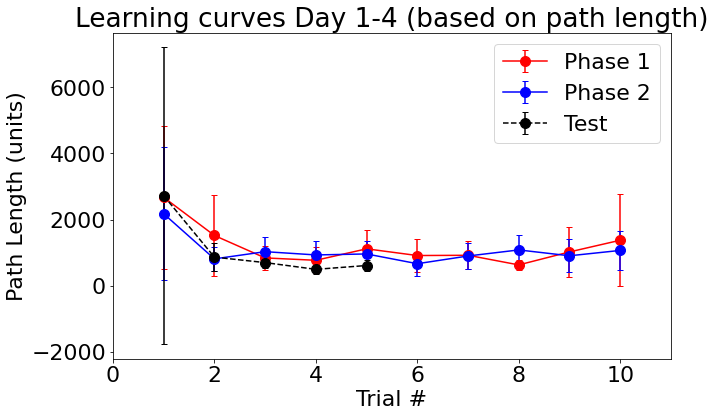

In [189]:
## Plotting Learning Curves based on path length

phase_1_mean = np.mean(phase_1_path, axis=0)
phase_1_std = np.std(phase_1_path, axis=0)

phase_2_mean = np.mean(phase_2_path, axis=0)
phase_2_std = np.std(phase_2_path, axis=0)

test_mean = np.mean(test_path, axis=0)
test_std = np.std(test_path, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")
plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Learning curves Day 1-4 (based on path length)")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curves-day1-4.png", dpi=600)
plt.show()

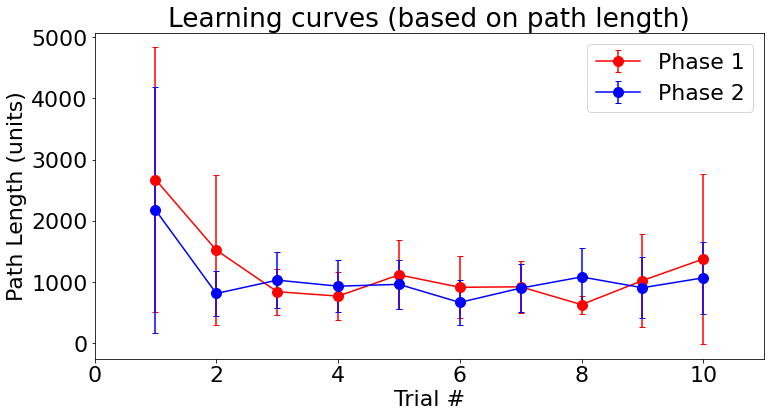

In [190]:
## Just Phase 1 and 2

## Plotting Learning Curves based on path length

phase_1_mean = np.mean(phase_1_path, axis=0)
phase_1_std = np.std(phase_1_path, axis=0)

phase_2_mean = np.mean(phase_2_path, axis=0)
phase_2_std = np.std(phase_2_path, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")

plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Learning curves (based on path length)")
plt.legend()
plt.savefig("RI_Experiment_Outputs/learning-curves-phase1-2.png", dpi=600)
plt.show()

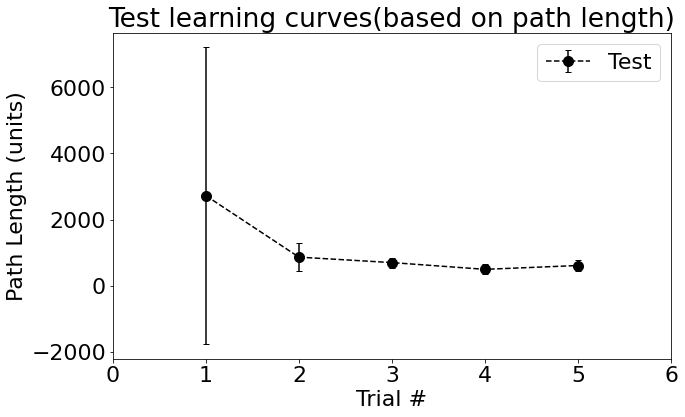

In [191]:
## Plotting Learning Curves based on path length

test_mean = np.mean(test_path, axis=0)
test_std = np.std(test_path, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

plt.xlim([0, 6]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Test learning curves(based on path length)")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curves-day1-4.png", dpi=600)
plt.show()

In [192]:
## Plotting Test Learning Curve - Separate by 1hr vs 4hr

downtime_4hr = []
downtime_1hr = []

downtime_sesh_num = 4

for i in range(downtime_sesh_num):
    downtime_4hr.append(test_path[2*i]) # even numbers
    downtime_1hr.append(test_path[2*i + 1]) # odd numbers

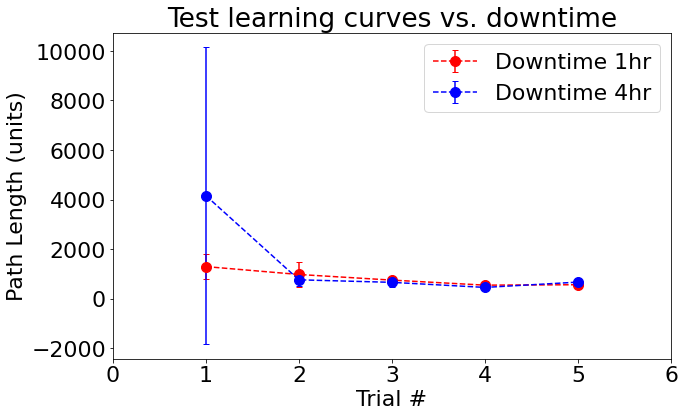

In [193]:
## Plotting test - separate by downtime

test_1hr_mean = np.mean(downtime_1hr, axis=0)
test_1hr_std = np.std(downtime_1hr, axis=0)

test_4hr_mean = np.mean(downtime_4hr, axis=0)
test_4hr_std = np.std(downtime_4hr, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})


## Plots with error bar
plt.errorbar(t[0:5], test_1hr_mean, yerr=test_1hr_std, capsize=3, markersize=markersize, fmt="r--o", ecolor = "red", label="Downtime 1hr")
plt.errorbar(t[0:5], test_4hr_mean, yerr=test_4hr_std, capsize=3, markersize=markersize, fmt="b--o", ecolor = "blue", label="Downtime 4hr")

plt.xlim([0, 6]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Test learning curves vs. downtime")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curves-test-day1-4-downtime.png", dpi=600)
plt.show()

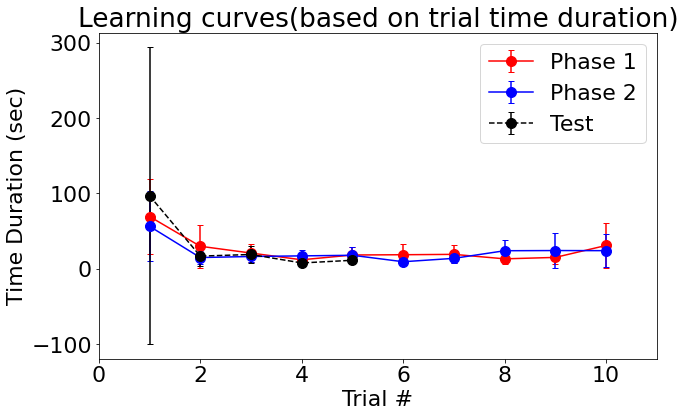

In [194]:
## Plotting Learning Curves based on trial time duration

phase_1_mean = np.mean(phase_1_time, axis=0)
phase_1_std = np.std(phase_1_time, axis=0)

phase_2_mean = np.mean(phase_2_time, axis=0)
phase_2_std = np.std(phase_2_time, axis=0)

test_mean = np.mean(test_time, axis=0)
test_std = np.std(test_time, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")
plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Time Duration (sec)")
plt.title("Learning curves(based on trial time duration)")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curves-day1-4-time_duration.png", dpi=600)
plt.show()

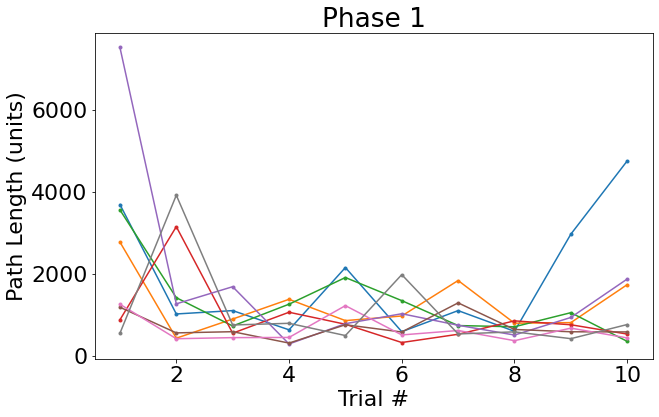

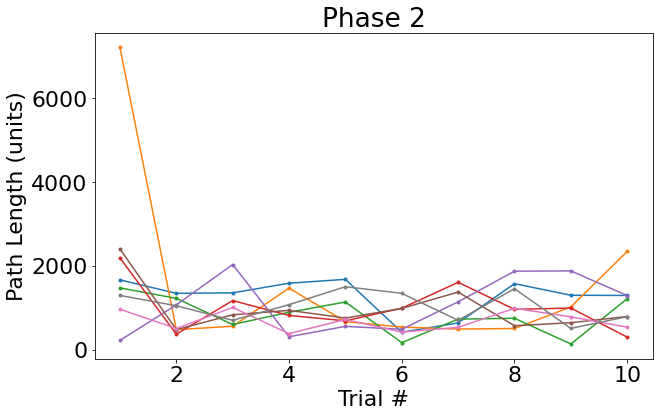

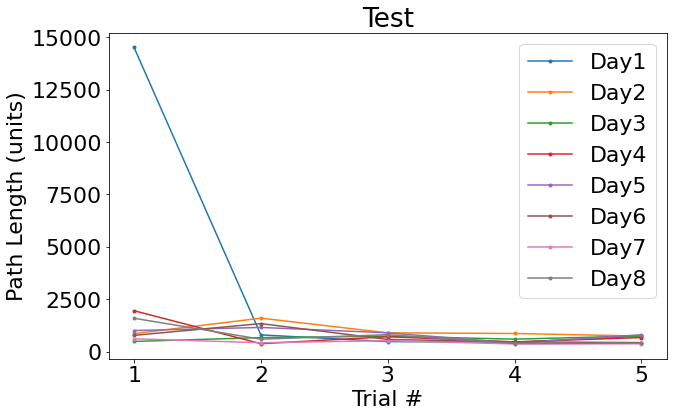

In [195]:
##### Code to plot each individual trial - Phase 1

plt.figure(figsize=(10,6))

for i in range(num_days):
    label_str = "Day" + str(i+1)
    plt.plot(t, phase_1_path[i], ".-", label=label_str)

plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
# plt.ylim([0, 4000]) # limits to keep plot scales consistent
# plt.legend()
plt.title("Phase 1")
plt.savefig("RI_Experiment_Outputs/phase1_outliers.png", dpi=600)
plt.show()

##### Code to plot each individual trial - Phase 2

plt.figure(figsize=(10,6))

for i in range(num_days):
    label_str = "Day" + str(i+1)
    plt.plot(t, phase_2_path[i], ".-", label=label_str)

plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
# plt.ylim([0, 4000])
# plt.legend()
plt.title("Phase 2")
plt.savefig("RI_Experiment_Outputs/phase2_outliers.png", dpi=600)
plt.show()

## Code to plot each individual trial - Test
plt.figure(figsize=(10,6))

day_index = 0

for i in range(num_days):
    label_str = "Day" + str(i+1)
    plt.plot(t[0:5], test_path[i], ".-", label=label_str)

plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
# plt.ylim([0, 4000])
plt.legend()
plt.title("Test")
# plt.savefig("RI_Experiment_Outputs/test_outliers.png", dpi=600)
plt.show()


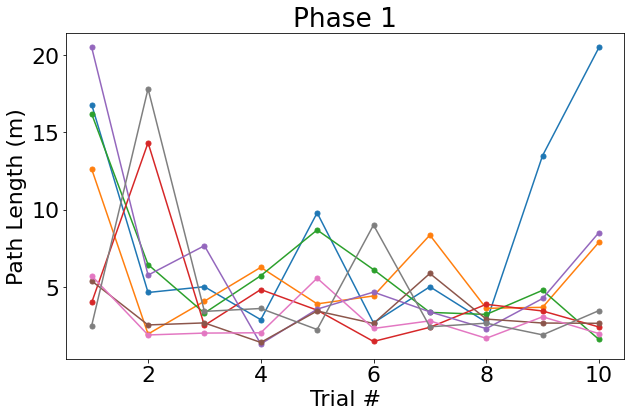

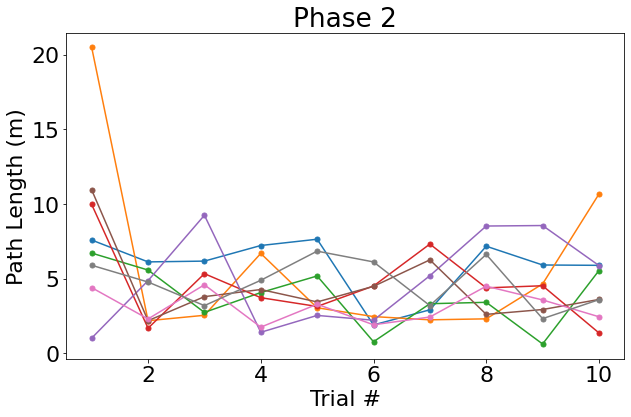

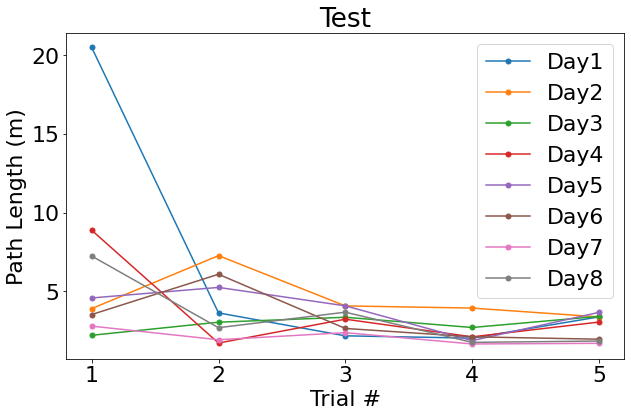

In [196]:
## Scaling individual trials

##### Code to plot each individual trial - Phase 1

# set upper limit for outliers ~ 4500cm
upper_limit = 4500*ratio/100
phase1_scaled = []
phase2_scaled = []
test_scaled = []

plt.figure(figsize=(10,6))

for i in range(num_days):
    label_str = "Day" + str(i+1)
    scaled = np.array(phase_1_path[i])*ratio/100
    scaled = np.where(scaled>upper_limit, upper_limit, scaled)
    phase1_scaled.append(scaled)
    plt.plot(t, scaled, ".-", label=label_str, markersize=10)

plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
# plt.ylim([0, 4000]) # limits to keep plot scales consistent
# plt.legend()
plt.title("Phase 1")
# plt.savefig("RI_Experiment_Outputs/phase1_scaled.png", dpi=600)
plt.show()

##### Code to plot each individual trial - Phase 2

plt.figure(figsize=(10,6))

for i in range(num_days):
    label_str = "Day" + str(i+1)
    scaled = np.array(phase_2_path[i])*ratio/100
    scaled = np.where(scaled>upper_limit, upper_limit, scaled)
    phase2_scaled.append(scaled)
    plt.plot(t, scaled, ".-", label=label_str,markersize=10)

plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
# plt.ylim([0, 4000])
# plt.legend()
plt.title("Phase 2")
# plt.savefig("RI_Experiment_Outputs/phase2_scaled.png", dpi=600)
plt.show()

## Code to plot each individual trial - Test
plt.figure(figsize=(10,6))

day_index = 0

for i in range(num_days):
    label_str = "Day" + str(i+1)
    scaled = np.array(test_path[i])*ratio/100
    scaled = np.where(scaled>upper_limit, upper_limit, scaled)
    test_scaled.append(scaled)
    plt.plot(t[0:5], scaled, ".-", label=label_str,markersize=10)

plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
# plt.ylim([0, 4000])
plt.legend()
plt.title("Test")
# plt.savefig("RI_Experiment_Outputs/test_scaled.png", dpi=600)
plt.show()



In [135]:
phase1_scaled

array([ 2.50320085, 17.82489181,  3.41972476,  3.60678315,  2.24648126,
        9.00848698,  2.42499545,  2.65725718,  1.90104721,  3.47030231])

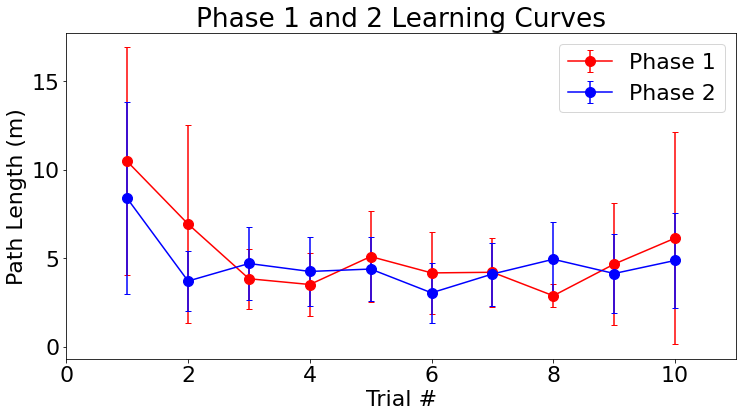

In [197]:
## Just Phase 1 and 2
# phase1_scaled = []
# phase2_scaled = []
# test_scaled = []
## Plotting Learning Curves based on path length

phase_1_mean = np.mean(phase1_scaled, axis=0)
phase_1_std = np.std(phase1_scaled, axis=0)

phase_2_mean = np.mean(phase2_scaled, axis=0)
phase_2_std = np.std(phase2_scaled, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")

plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Phase 1 and 2 Learning Curves")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/phase1-2_scaled_learning_curve.png", dpi=600)
plt.show()

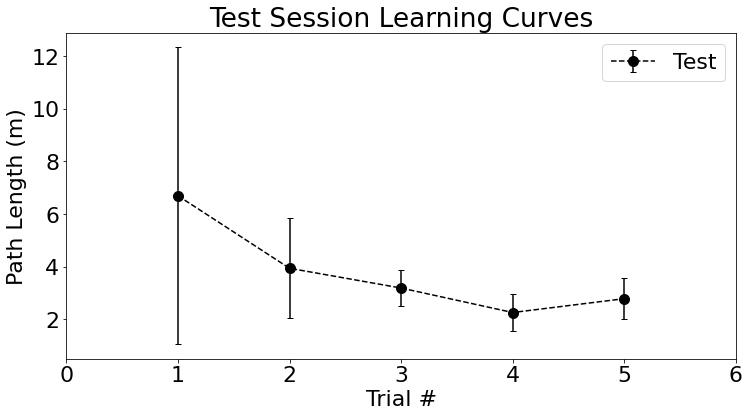

In [198]:
## Just Test 

# test_scaled = []
## Plotting Learning Curves based on path length

test_mean = np.mean(test_scaled, axis=0)
test_std = np.std(test_scaled, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

plt.xlim([0, 6]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Test Session Learning Curves")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/test_scaled_learning_curve.png", dpi=600)
plt.show()

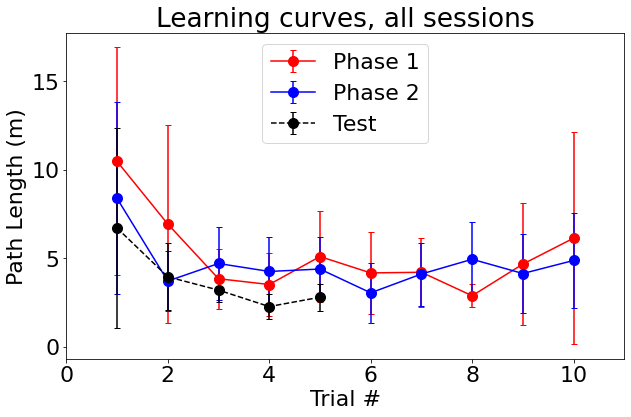

In [199]:
## Plotting Learning Curves based on path length

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")
plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Learning curves, all sessions")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curves-all-sessions.png", dpi=600)
plt.show()

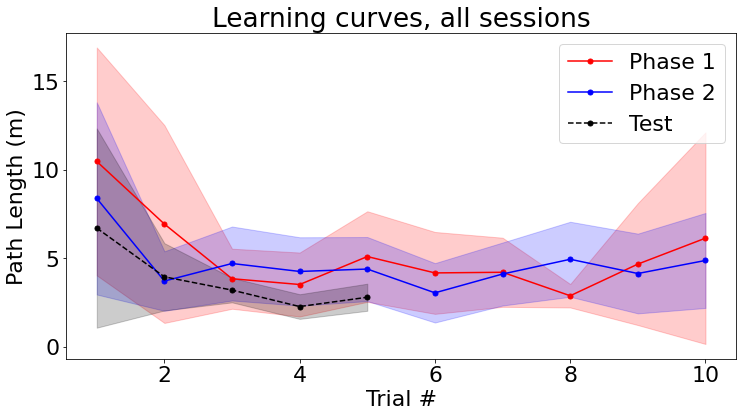

In [200]:
## Plotting Learning Curves based on path length

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
# plt.errorbar(t, phase_1_mean, yerr=phase_1_std, capsize=3, markersize=markersize, fmt="r-o", ecolor = "red", label="Phase 1")
# plt.errorbar(t, phase_2_mean, yerr=phase_2_std, capsize=3, markersize=markersize, fmt="b-o", ecolor = "blue", label="Phase 2")
# plt.errorbar(t[0:5], test_mean, yerr=test_std, capsize=3, markersize=markersize, fmt="k--o", ecolor = "black", label="Test")

# Plot the mean line
plt.plot(t, phase_1_mean, ".-", color='red', label='Phase 1', markersize=10)
plt.fill_between(t, phase_1_mean - phase_1_std, phase_1_mean + phase_1_std, color='red', alpha=0.2)

plt.plot(t, phase_2_mean, ".-", color='blue', label='Phase 2', markersize=10)
plt.fill_between(t, phase_2_mean - phase_2_std, phase_2_mean + phase_2_std, color='blue', alpha=0.2)

plt.plot(t[0:5], test_mean, ".--", color='black', label='Test', markersize=10)
plt.fill_between(t[0:5], test_mean - test_std, test_mean + test_std, color='black', alpha=0.2)


# plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Learning curves, all sessions")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curves-all-sessions-shaded.png", dpi=600)
plt.show()

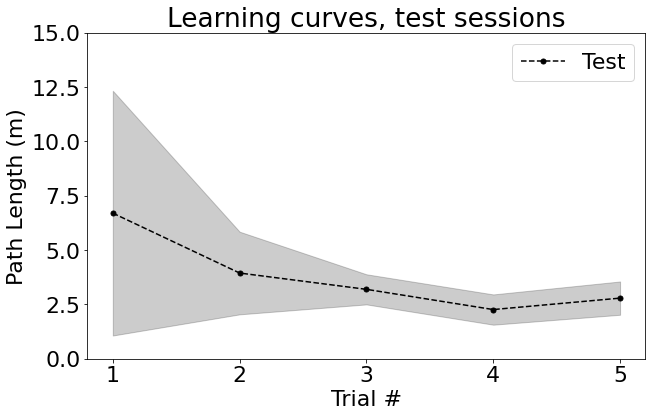

In [201]:
## Plotting Learning Curves based on path length

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})


plt.plot(t[0:5], test_mean, ".--", color='black', label='Test', markersize=10)
plt.fill_between(t[0:5], test_mean - test_std, test_mean + test_std, color='black', alpha=0.2)


# plt.xlim([0, 11]) # limits to keep plot scales consistent
plt.ylim([0, 15])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Learning curves, test sessions")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curve-test-sessions-shaded.png", dpi=600)
plt.show()

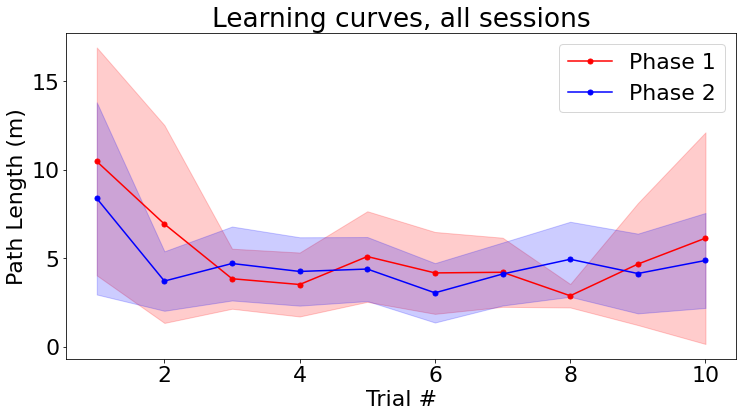

In [202]:
## Plotting Learning Curves based on path length

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})


# Plot the mean line
plt.plot(t, phase_1_mean, ".-", color='red', label='Phase 1', markersize=10)
plt.fill_between(t, phase_1_mean - phase_1_std, phase_1_mean + phase_1_std, color='red', alpha=0.2)

plt.plot(t, phase_2_mean, ".-", color='blue', label='Phase 2', markersize=10)
plt.fill_between(t, phase_2_mean - phase_2_std, phase_2_mean + phase_2_std, color='blue', alpha=0.2)


# plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Learning curves, all sessions")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/learning-curves-phases1-2-shaded.png", dpi=600)
plt.show()

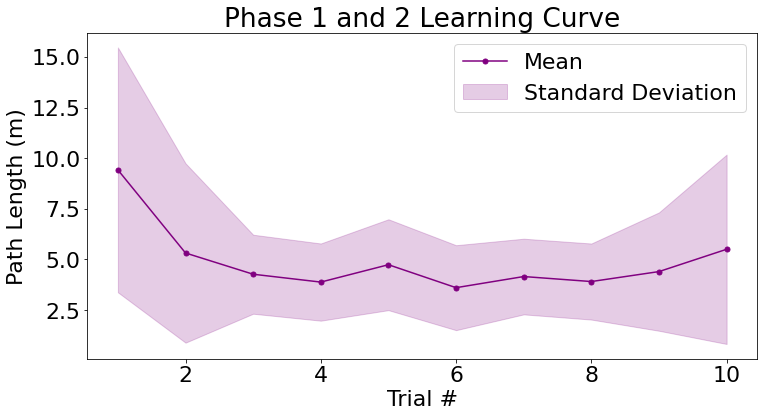

In [203]:
np.shape(phase1_scaled)

np.shape(phase2_scaled)

join_phase_1_2 = np.concatenate((phase1_scaled,phase2_scaled))

## Plotting Learning Curves based on path length

join_phases_mean = np.mean(join_phase_1_2, axis=0)
join_phases_std = np.std(join_phase_1_2, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

## Plots without error bar
# plt.plot(t, phase_1_mean, "r.-", markersize=markersize, label="Phase 1")
# plt.plot(t, phase_2_mean, "b.-", markersize=markersize, label="Phase 2")
# plt.plot(t[0:5], test_mean, "k.--", markersize=markersize, label="Test")

## Plots with error bar
# plt.errorbar(t, join_phases_mean, yerr=join_phases_std, capsize=3, markersize=markersize, fmt="-o", color="purple", ecolor = "purple", label="Phase 1")

# Plot the mean line
plt.plot(t, join_phases_mean, ".-", color='purple', label='Mean', markersize=10)

# Shade the standard deviation area
plt.fill_between(t, join_phases_mean - join_phases_std, join_phases_mean + join_phases_std, color='purple', alpha=0.2, label='Standard Deviation')


# plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Phase 1 and 2 Learning Curve")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/join_phase1-2_scaled_learning_curve.png", dpi=600)
plt.show()

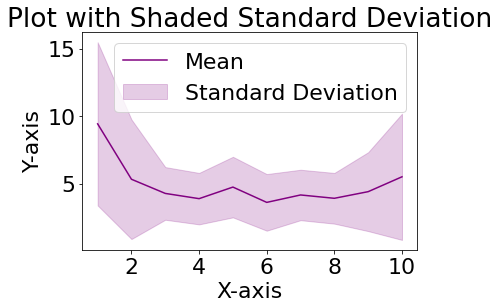

In [158]:
# Sample data (replace with your actual data)

# Plot the mean line
plt.plot(t, join_phases_mean, color='purple', label='Mean')

# Shade the standard deviation area
plt.fill_between(t, join_phases_mean - join_phases_std, join_phases_mean + join_phases_std, color='purple', alpha=0.2, label='Standard Deviation')

# Add labels and title
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Plot with Shaded Standard Deviation')

# Add legend
plt.legend()

# Show the plot
plt.show()

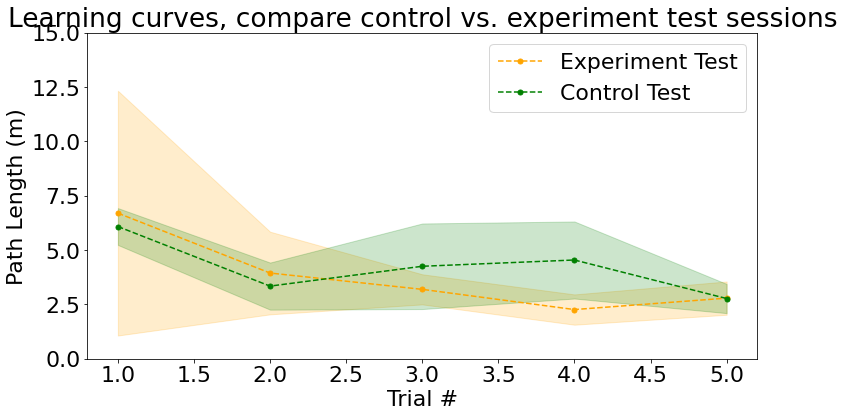

In [212]:
phase_1_mean = np.mean(phase1_scaled, axis=0)
phase_1_std = np.std(phase1_scaled, axis=0)

phase_2_mean = np.mean(phase2_scaled, axis=0)
phase_2_std = np.std(phase2_scaled, axis=0)

test_mean = np.mean(test_scaled, axis=0)
test_std = np.std(test_scaled, axis=0)

control_test_mean = np.mean(control_test_data, axis=0)
control_test_std = np.std(control_test_data, axis=0)

## Plotting Learning Curves based on path length

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

plt.plot(t[0:5], test_mean, ".--", color='orange', label='Experiment Test', markersize=10)
plt.fill_between(t[0:5], test_mean - test_std, test_mean + test_std, color='orange', alpha=0.2)

plt.plot(t[0:5], control_test_mean, ".--", color='green', label='Control Test', markersize=10)
plt.fill_between(t[0:5], control_test_mean - control_test_std, control_test_mean + control_test_std, color='green', alpha=0.2)

# plt.xlim([0, 11]) # limits to keep plot scales consistent
plt.ylim([0, 15])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Learning curves, compare control vs. experiment test sessions")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/compare-control-experiment-test-shaded.png", dpi=600)
plt.show()


In [187]:
test_path_scaled

[]

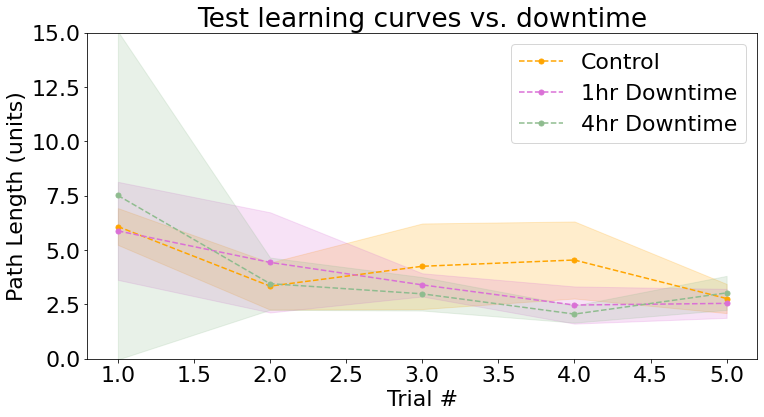

In [328]:

## Plotting Test Learning Curve - Separate by 1hr vs 4hr

downtime_4hr = []
downtime_1hr = []

downtime_sesh_num = 4

for i in range(downtime_sesh_num):
    downtime_4hr.append(test_scaled[2*i]) # even numbers
    downtime_1hr.append(test_scaled[2*i + 1]) # odd numbers
    
    
test_1hr_mean = np.mean(downtime_1hr, axis=0)
test_1hr_std = np.std(downtime_1hr, axis=0)

test_4hr_mean = np.mean(downtime_4hr, axis=0)
test_4hr_std = np.std(downtime_4hr, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})


## Plots with error bar
plt.plot(t[0:5], control_test_mean, ".--", color='orange', label='Control', markersize=10)
plt.fill_between(t[0:5], control_test_mean - control_test_std, control_test_mean + control_test_std, color='orange', alpha=0.2)

plt.plot(t[0:5], test_1hr_mean, ".--", color='orchid', label='1hr Downtime', markersize=10)
plt.fill_between(t[0:5], test_1hr_mean - test_1hr_std, test_1hr_mean + test_1hr_std, color='orchid', alpha=0.2)

plt.plot(t[0:5], test_4hr_mean, ".--", color='darkseagreen', label='4hr Downtime', markersize=10)
plt.fill_between(t[0:5], test_4hr_mean - test_4hr_std, test_4hr_mean + test_4hr_std, color='darkseagreen', alpha=0.2)


# plt.errorbar(t[0:5], test_1hr_mean, yerr=test_1hr_std, capsize=3, markersize=markersize, fmt="r--o", ecolor = "red", label="Downtime 1hr")
# plt.errorbar(t[0:5], test_4hr_mean, yerr=test_4hr_std, capsize=3, markersize=markersize, fmt="b--o", ecolor = "blue", label="Downtime 4hr")

# plt.xlim([0, 6]) # limits to keep plot scales consistent
plt.ylim([0, 15])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Test learning curves vs. downtime")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/compare-test-control-downtime.png", dpi=600)
plt.show()

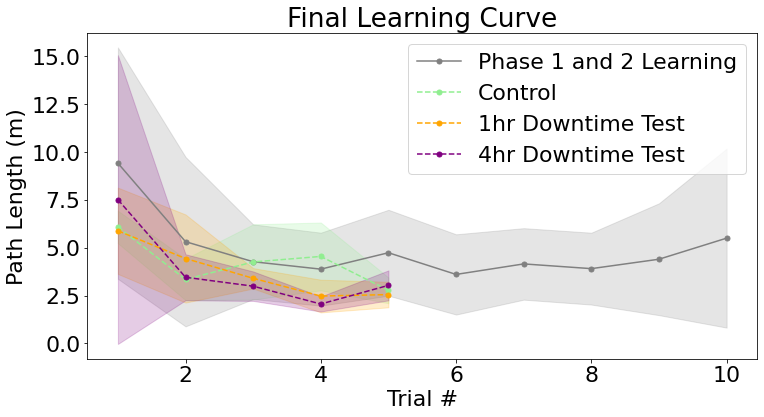

In [339]:
np.shape(phase1_scaled)

np.shape(phase2_scaled)

join_phase_1_2 = np.concatenate((phase1_scaled,phase2_scaled))

## Plotting Learning Curves based on path length

join_phases_mean = np.mean(join_phase_1_2, axis=0)
join_phases_std = np.std(join_phase_1_2, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

plt.plot(t, join_phases_mean, ".-", color='gray', label='Phase 1 and 2 Learning', markersize=10)
plt.fill_between(t, join_phases_mean - join_phases_std, join_phases_mean + join_phases_std, color='gray', alpha=0.2)

plt.plot(t[0:5], control_test_mean, ".--", color='lightgreen', label='Control', markersize=10)
plt.fill_between(t[0:5], control_test_mean - control_test_std, control_test_mean + control_test_std, color='lightgreen', alpha=0.2)

plt.plot(t[0:5], test_1hr_mean, ".--", color='orange', label='1hr Downtime Test', markersize=10)
plt.fill_between(t[0:5], test_1hr_mean - test_1hr_std, test_1hr_mean + test_1hr_std, color='orange', alpha=0.2)

plt.plot(t[0:5], test_4hr_mean, ".--", color='purple', label='4hr Downtime Test', markersize=10)
plt.fill_between(t[0:5], test_4hr_mean - test_4hr_std, test_4hr_mean + test_4hr_std, color='purple', alpha=0.2)



# plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Final Learning Curve")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/comparison_learning_curve.png", dpi=600)
plt.show()

In [ ]:
np.shape(phase1_scaled)

np.shape(phase2_scaled)

join_phase_1_2 = np.concatenate((phase1_scaled,phase2_scaled))

## Plotting Learning Curves based on path length

join_phases_mean = np.mean(join_phase_1_2, axis=0)
join_phases_std = np.std(join_phase_1_2, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})

plt.plot(t, join_phases_mean, ".-", color='gray', label='Phase 1 and 2 Learning', markersize=10)
plt.fill_between(t, join_phases_mean - join_phases_std, join_phases_mean + join_phases_std, color='gray', alpha=0.2)

plt.plot(t[0:5], test_1hr_mean, ".--", color='orange', label='1hr Downtime Test', markersize=10)
plt.fill_between(t[0:5], test_1hr_mean - test_1hr_std, test_1hr_mean + test_1hr_std, color='orange', alpha=0.2)

plt.plot(t[0:5], test_4hr_mean, ".--", color='purple', label='4hr Downtime Test', markersize=10)
plt.fill_between(t[0:5], test_4hr_mean - test_4hr_std, test_4hr_mean + test_4hr_std, color='purple', alpha=0.2)

# plt.xlim([0, 11]) # limits to keep plot scales consistent
# plt.ylim([0, 3000])
plt.xlabel("Trial #")
plt.ylabel("Path Length (m)")
plt.title("Final Learning Curve")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/final_learning_curve.png", dpi=600)
plt.show()

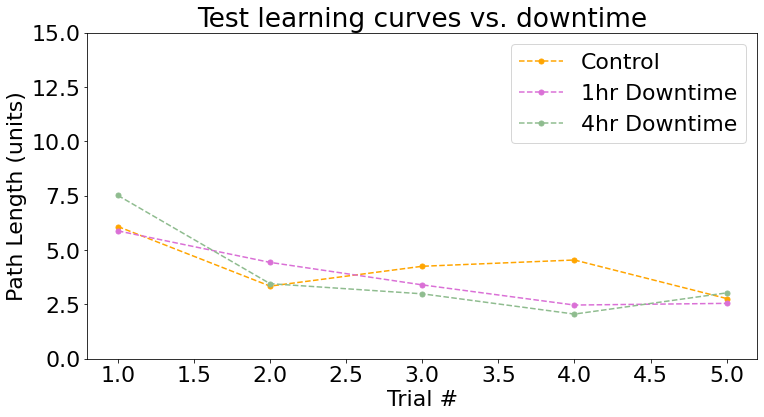

In [327]:

## Plotting Test Learning Curve - Separate by 1hr vs 4hr

downtime_4hr = []
downtime_1hr = []

downtime_sesh_num = 4

for i in range(downtime_sesh_num):
    downtime_4hr.append(test_scaled[2*i]) # even numbers
    downtime_1hr.append(test_scaled[2*i + 1]) # odd numbers
    
    
test_1hr_mean = np.mean(downtime_1hr, axis=0)
test_1hr_std = np.std(downtime_1hr, axis=0)

test_4hr_mean = np.mean(downtime_4hr, axis=0)
test_4hr_std = np.std(downtime_4hr, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (12,6))
plt.rcParams.update({'font.size': 22})


## Plots with error bar
plt.plot(t[0:5], control_test_mean, ".--", color='orange', label='Control', markersize=10)
# plt.fill_between(t[0:5], control_test_mean - control_test_std, control_test_mean + control_test_std, color='orange', alpha=0.2)

plt.plot(t[0:5], test_1hr_mean, ".--", color='orchid', label='1hr Downtime', markersize=10)
# plt.fill_between(t[0:5], test_1hr_mean - test_1hr_std, test_1hr_mean + test_1hr_std, color='orchid', alpha=0.2)

plt.plot(t[0:5], test_4hr_mean, ".--", color='darkseagreen', label='4hr Downtime', markersize=10)
# plt.fill_between(t[0:5], test_4hr_mean - test_4hr_std, test_4hr_mean + test_4hr_std, color='darkseagreen', alpha=0.2)


# plt.errorbar(t[0:5], test_1hr_mean, yerr=test_1hr_std, capsize=3, markersize=markersize, fmt="r--o", ecolor = "red", label="Downtime 1hr")
# plt.errorbar(t[0:5], test_4hr_mean, yerr=test_4hr_std, capsize=3, markersize=markersize, fmt="b--o", ecolor = "blue", label="Downtime 4hr")

# plt.xlim([0, 6]) # limits to keep plot scales consistent
plt.ylim([0, 15])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Test learning curves vs. downtime")
plt.legend()
# plt.savefig("RI_Experiment_Outputs/compare-test-control-downtime-no-std.png", dpi=600)
plt.show()

In [ ]:

## Plotting Test Learning Curve - Separate by 1hr vs 4hr

downtime_4hr = []
downtime_1hr = []

downtime_sesh_num = 4

for i in range(downtime_sesh_num):
    downtime_4hr.append(test_scaled[2*i]) # even numbers
    downtime_1hr.append(test_scaled[2*i + 1]) # odd numbers
    
    
test_1hr_mean = np.mean(downtime_1hr, axis=0)
test_1hr_std = np.std(downtime_1hr, axis=0)

test_4hr_mean = np.mean(downtime_4hr, axis=0)
test_4hr_std = np.std(downtime_4hr, axis=0)

fontsize = 20
markersize = 10
plt.figure(figsize = (10,6))
plt.rcParams.update({'font.size': 22})


## Plots with error bar
plt.plot(t[0:5], test_1hr_mean, ".--", color='orchid', label='1hr Downtime', markersize=10)
plt.fill_between(t[0:5], test_1hr_mean - test_1hr_std, test_1hr_mean + test_1hr_std, color='orchid', alpha=0.2)

plt.plot(t[0:5], test_4hr_mean, ".--", color='darkseagreen', label='4hr Downtime', markersize=10)
plt.fill_between(t[0:5], test_4hr_mean - test_4hr_std, test_4hr_mean + test_4hr_std, color='darkseagreen', alpha=0.2)


# plt.errorbar(t[0:5], test_1hr_mean, yerr=test_1hr_std, capsize=3, markersize=markersize, fmt="r--o", ecolor = "red", label="Downtime 1hr")
# plt.errorbar(t[0:5], test_4hr_mean, yerr=test_4hr_std, capsize=3, markersize=markersize, fmt="b--o", ecolor = "blue", label="Downtime 4hr")

# plt.xlim([0, 6]) # limits to keep plot scales consistent
plt.ylim([0, 15])
plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.title("Test learning curves vs. downtime")
plt.legend()
plt.savefig("RI_Experiment_Outputs/test-learning-curve-downtime.png", dpi=600)
plt.show()

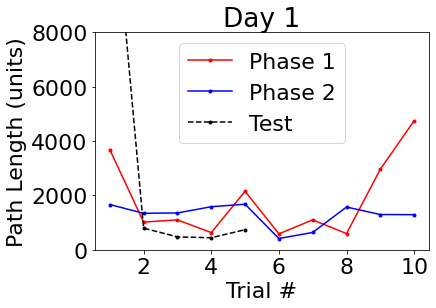

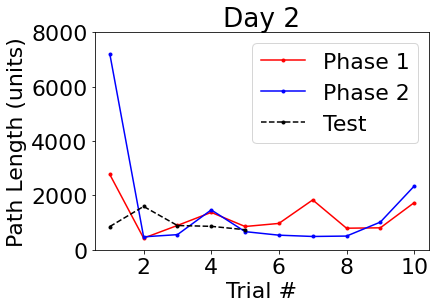

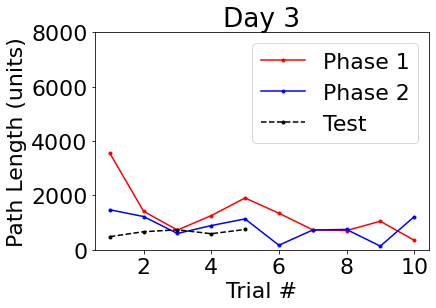

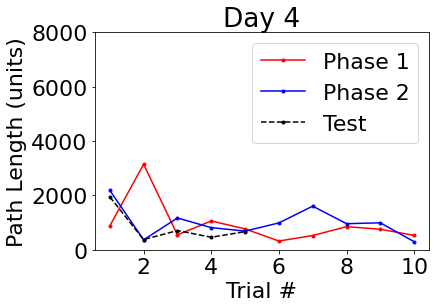

In [57]:
##### Code to plot each individual trial - Day 1

day_index = 0

plt.plot(t, phase_1_path[day_index], "r.-", label="Phase 1")
plt.plot(t, phase_2_path[day_index], "b.-", label="Phase 2")
plt.plot(t[0:5], test_path[day_index], "k.--", label="Test")

plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.ylim([0, 8000])
plt.legend()
plt.title("Day 1")
# plt.savefig("RI_Experiment_Outputs/day1.png", dpi=600)
plt.show()

##### Code to plot each individual trial - Day 2

day_index = 1

plt.plot(t, phase_1_path[day_index], "r.-", label="Phase 1")
plt.plot(t, phase_2_path[day_index], "b.-", label="Phase 2")
plt.plot(t[0:5], test_path[day_index], "k.--", label="Test")

plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.ylim([0, 8000]) # limits to keep plot scales consistent
plt.legend()
plt.title("Day 2")
# plt.savefig("RI_Experiment_Outputs/day2.png", dpi=600)
plt.show()

##### Code to plot each individual trial - Day 3

day_index = 2

plt.plot(t, phase_1_path[day_index], "r.-", label="Phase 1")
plt.plot(t, phase_2_path[day_index], "b.-", label="Phase 2")
plt.plot(t[0:5], test_path[day_index], "k.--", label="Test")

plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.ylim([0, 8000])
plt.legend()
plt.title("Day 3")
# plt.savefig("RI_Experiment_Outputs/day3.png", dpi=600)
plt.show()

##### Code to plot each individual trial - Day 3

day_index = 3

plt.plot(t, phase_1_path[day_index], "r.-", label="Phase 1")
plt.plot(t, phase_2_path[day_index], "b.-", label="Phase 2")
plt.plot(t[0:5], test_path[day_index], "k.--", label="Test")

plt.xlabel("Trial #")
plt.ylabel("Path Length (units)")
plt.ylim([0, 8000])
plt.legend()
plt.title("Day 4")
# plt.savefig("RI_Experiment_Outputs/day4.png", dpi=600)
plt.show()

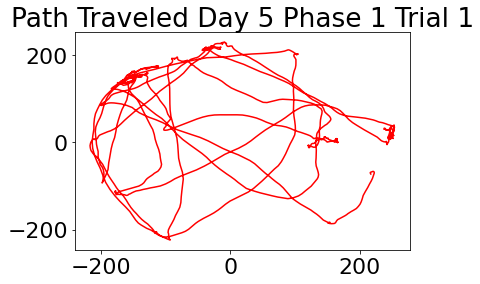

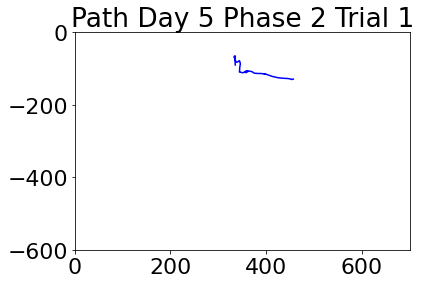

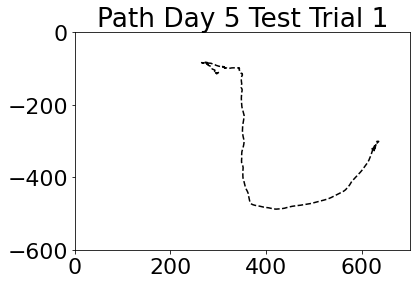

In [64]:
## Sample Plotting Single Position Data Trial

day_num = 4 # ranges 0 to 3
trial_num = 0 # ranges 0 to 9 (or 0 to 4 for test session)

## Code to plot one single path traversal
# sample code for phase 1 data
x = phase_1_positions[day_num][trial_num][0] - x_center # x positions
y = phase_1_positions[day_num][trial_num][1] + y_center # y positions

plt.plot(x,y,color="red")

    
# plt.xlim([0, 700]) # limits to keep plot scales consistent
# plt.ylim([-600, 0])
plt.title("Path Traveled Day %s Phase 1 Trial %s" % (day_num+1, trial_num+1)) # Using special string formatting
plt.show()

## Sample Plotting Single Position Data Trial

## Code to plot one single path traversal
# sample code for phase 1 data
x = phase_2_positions[day_num][trial_num][0] # x positions
y = phase_2_positions[day_num][trial_num][1] # y positions

plt.plot(x,y,color="blue")
plt.xlim([0, 700]) # limits to keep plot scales consistent
plt.ylim([-600, 0])
plt.title("Path Day %s Phase 2 Trial %s" % (day_num+1, trial_num+1)) # Using special string formatting
plt.show()

## Sample Plotting Single Position Data Trial

## Code to plot one single path traversal
# sample code for phase 1 data
x = test_positions[day_num][trial_num][0] # x positions
y = test_positions[day_num][trial_num][1] # y positions

plt.plot(x,y,'--', color="black")
plt.xlim([0, 700]) # limits to keep plot scales consistent
plt.ylim([-600, 0])
plt.title("Path Day %s Test Trial %s" % (day_num+1, trial_num+1)) # Using special string formatting
plt.show()

In [42]:
radius

245.9

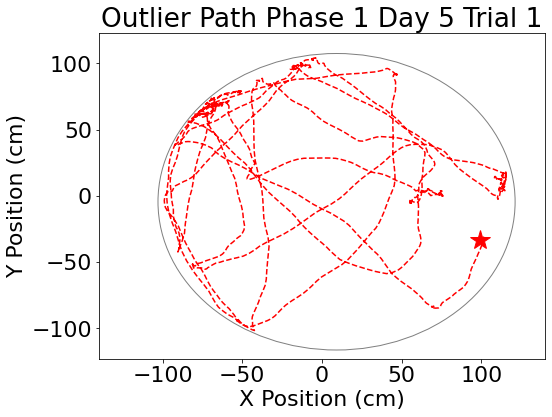

In [106]:
## Sample Plotting Single Position Data Trial

day_num = 4 # ranges 0 to 3
trial_num = 0 # ranges 0 to 9 (or 0 to 4 for test session)

plt.figure(figsize=(8,6))
## Code to plot one single path traversal
# sample code for phase 1 data
x = phase_1_positions[day_num][trial_num][0] - x_center # x positions
y = phase_1_positions[day_num][trial_num][1] + y_center # y positions

circle1 = plt.Circle((20*ratio, -10*ratio), radius*ratio, color='gray', fill = None)
plt.gca().add_patch(circle1)
    
plt.plot(x*ratio,y*ratio,"--", color="red")
plt.plot(x[-1]*ratio,y[-1]*ratio,"*", color="red", markersize=20)

plt.xlim([-1.25*radius*ratio, 1.25*radius*ratio]) # limits to keep plot scales consistent
plt.ylim([-1.1*radius*ratio, 1.1*radius*ratio])
plt.title("Outlier Path Phase 1 Day %s Trial %s" % (day_num+1, trial_num+1)) # Using special string formatting
plt.xlabel("X Position (cm)")
plt.ylabel("Y Position (cm)")
# plt.savefig("RI_Experiment_Outputs/phase1_outlier_path.png", dpi=600)
plt.show()

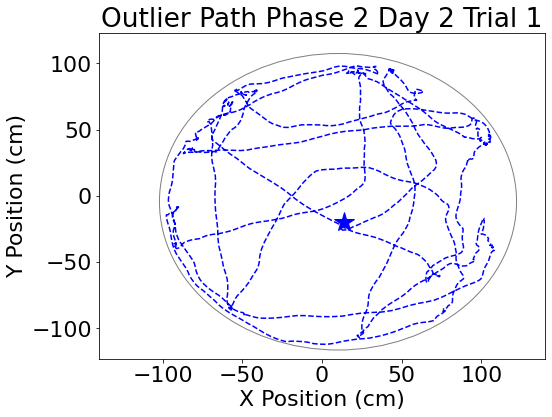

In [105]:
day_num = 1 # ranges 0 to 3
trial_num = 0 # ranges 0 to 9 (or 0 to 4 for test session)

plt.figure(figsize=(8,6))
## Code to plot one single path traversal
# sample code for phase 1 data
x = phase_2_positions[day_num][trial_num][0] - x_center # x positions
y = phase_2_positions[day_num][trial_num][1] + y_center # y positions

circle1 = plt.Circle((22*ratio, -10*ratio), radius*ratio, color='gray', fill = None)
plt.gca().add_patch(circle1)
    
plt.plot(x*ratio,y*ratio,"--", color="blue")
plt.plot(x[-1]*ratio,y[-1]*ratio,"*", color="blue", markersize=20)

plt.xlim([-1.25*radius*ratio, 1.25*radius*ratio]) # limits to keep plot scales consistent
plt.ylim([-1.1*radius*ratio, 1.1*radius*ratio])
plt.title("Outlier Path Phase 2 Day %s Trial %s" % (day_num+1, trial_num+1)) # Using special string formatting
plt.xlabel("X Position (cm)")
plt.ylabel("Y Position (cm)")
# plt.savefig("RI_Experiment_Outputs/phase2_outlier_path.png", dpi=600)
plt.show()

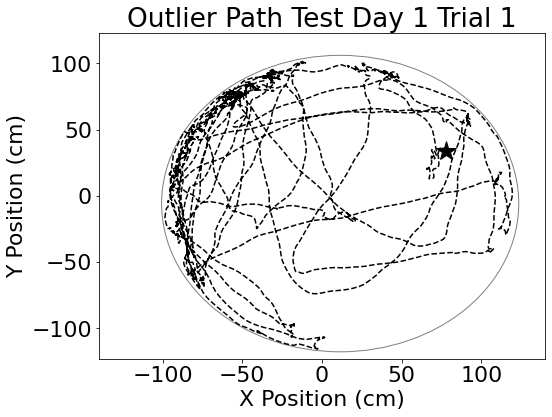

In [104]:
day_num = 0 # ranges 0 to 3
trial_num = 0 # ranges 0 to 9 (or 0 to 4 for test session)

plt.figure(figsize=(8,6))
## Code to plot one single path traversal
# sample code for phase 1 data
x = test_positions[day_num][trial_num][0] - x_center # x positions
y = test_positions[day_num][trial_num][1] + y_center # y positions

circle1 = plt.Circle((25*ratio, -13*ratio), radius*ratio, color='gray', fill = None)
plt.gca().add_patch(circle1)
    
plt.plot(x*ratio,y*ratio,"--", color="black")
plt.plot(x[-1]*ratio,y[-1]*ratio,"*", color="black", markersize=20)

plt.xlim([-1.25*radius*ratio, 1.25*radius*ratio]) # limits to keep plot scales consistent
plt.ylim([-1.1*radius*ratio, 1.1*radius*ratio])
plt.title("Outlier Path Test Day %s Trial %s" % (day_num+1, trial_num+1)) # Using special string formatting
plt.xlabel("X Position (cm)")
plt.ylabel("Y Position (cm)")
# plt.savefig("RI_Experiment_Outputs/test_outlier_path.png", dpi=600)
plt.show()

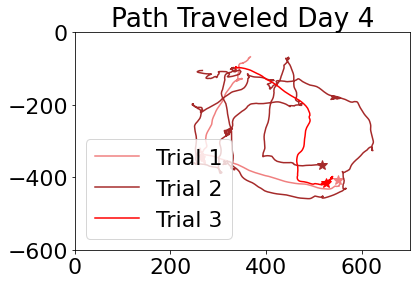

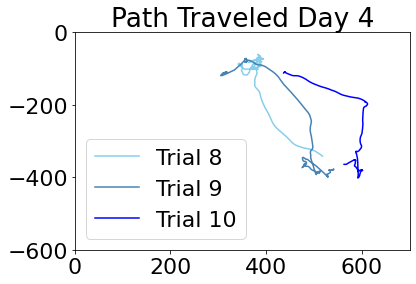

In [218]:
## Sample Plotting Position Data for Trials

red_colors = ["lightcoral", "brown", "red"]
blue_colors = ["skyblue", "steelblue", "blue"]

day_num = 3
trial_num = 0

for i in range(3): # first 3 trials
    x = phase_1_positions[day_num][i][0] # x positions
    y = phase_1_positions[day_num][i][1] # y positions
    plt.plot(x,y, color=red_colors[i], label = str("Trial " + str(i+1)))
    plt.plot(x[-1],y[-1], "*", color=red_colors[i], markersize=10)


plt.xlim([0, 700])
plt.ylim([-600, 0])
plt.legend()
plt.title("Path Traveled Day %s" % (day_num+1))
plt.show()

for i in [7,8,9]: # last 3 trials
    x = phase_1_positions[day_num][i][0] # x positions
    y = phase_1_positions[day_num][i][1] # y positions
    plt.plot(x,y, color=blue_colors[i%7], label = str("Trial " + str(i+1)))
    
plt.xlim([0, 700])
plt.ylim([-600, 0])
plt.legend()
plt.title("Path Traveled Day %s" % (day_num+1))
plt.show()

In [319]:
phase1_scaled[day_num][trial_num]*100

147.36002968202052

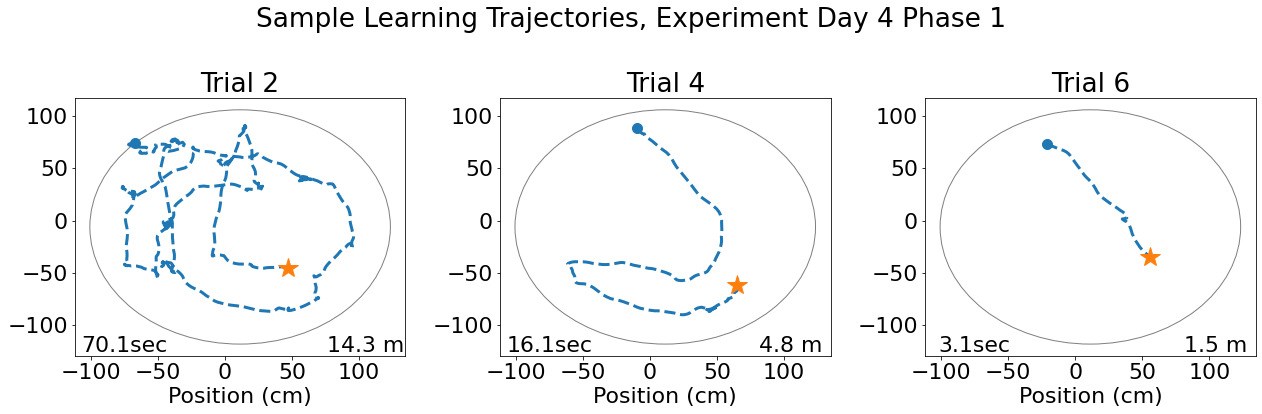

In [324]:
day_num = 3
count = 1

plt.figure(figsize=(18,6))

# plt.subplot(3, 1, 1)
# x = phase_1_positions[day_num][trial_num][0] - x_center # x positions
# y = phase_1_positions[day_num][trial_num][1] + y_center # y positions
# plt.plot(x,y, label = str("Trial " + str(count)))
# plt.plot(x[-1],y[-1], "*", markersize=10)

# plt.subplot(3, 1, 1)
# x = phase_1_positions[day_num][trial_num][0] - x_center # x positions
# y = phase_1_positions[day_num][trial_num][1] + y_center # y positions
# plt.plot(x,y, label = str("Trial " + str(count)))
# plt.plot(x[-1],y[-1], "*", markersize=10)

# plt.subplot(3, 1, 1)
# x = phase_1_positions[day_num][trial_num][0] - x_center # x positions
# y = phase_1_positions[day_num][trial_num][1] + y_center # y positions
# plt.plot(x,y, label = str("Trial " + str(count)))
# plt.plot(x[-1],y[-1], "*", markersize=10)

for trial_num in [1,3,5]: # first 3 trials
    plt.subplot(1,3, count)
    
    circle1 = plt.Circle((25*ratio, -13*ratio), radius*ratio, color='gray', fill = None)
    plt.gca().add_patch(circle1)

    x = (phase_1_positions[day_num][trial_num][0] - x_center)*ratio # x positions
    y = (phase_1_positions[day_num][trial_num][1] + y_center)*ratio # y positions
    plt.plot(x[0],y[0], ".", color="tab:blue", markersize=20)
    plt.plot(x,y, "--", color="tab:blue", label = str("Trial " + str(count)), linewidth=3)
    plt.plot(x[-1],y[-1], "*", color="tab:orange", markersize=20)
    plt.text(105, -120, "%.1f m" % phase1_scaled[day_num][trial_num],horizontalalignment='center', verticalalignment='center')
    plt.text(-75, -120, "%.1fsec" % phase_1_time[day_num][trial_num], horizontalalignment='center', verticalalignment='center')
    plt.title("Trial " + str(trial_num+1))
    plt.xlabel("Position (cm)")
    
    count += 1

plt.suptitle("Sample Learning Trajectories, Experiment Day " + str(day_num+1) + " Phase 1")
plt.tight_layout()
# plt.savefig("RI_Experiment_Outputs/sample_trajectories_day4.png")
plt.show()

In [39]:
x = positions_no_reward[0]
y = positions_no_reward[1]

print("x ---", "max = ", np.max(x), "min = ", np.min(x))

print("y ---", "max = ", np.max(y), "min = ", np.min(y))

x_center = np.mean([np.max(x), np.min(x)])
y_center = np.mean([np.max(y), np.min(y)])

x_diam = np.max(x) - np.min(x)
y_diam = np.max(y) - np.min(y)

radius = np.max([x_diam,y_diam])/2

print("New Center = ", x_center, y_center)

print("X and Y diameter = ", x_diam, y_diam)

print("Radius in pixels = ", radius)

x --- max =  656.6863213699668 min =  170.41989589011555
y --- max =  -22.8190537880864 min =  -514.6103095041823
New Center =  413.55310863004115 -268.71468164613435
X and Y diameter =  486.26642547985125 491.79125571609586
Radius in pixels =  245.89562785804793


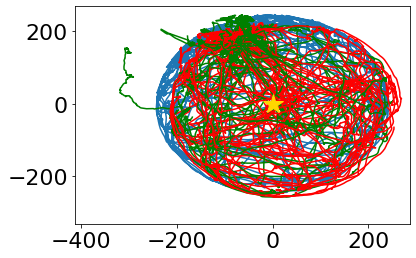

Trial count =  30


In [42]:
# Finding units of the cheeseboard

x = positions_no_reward[0] - x_center
y = positions_no_reward[1] - y_center

plt.plot(x,y)

count = 0

for i in range(10):
    for k in range(3):
        x = phase_1_positions[k][i][0] - x_center # x positions
        y = phase_1_positions[k][i][1] - y_center # y positions
        plt.plot(x,y,color="red")
        
        x = phase_2_positions[k][i][0] - x_center # x positions
        y = phase_2_positions[k][i][1] - y_center # y positions
        plt.plot(x,y,color="green")
        
        count += 1
        
plt.plot(x_center - x_center, y_center - y_center, "*", color="gold", markersize=20)
plt.xlim([0, 700] - x_center)
plt.ylim([-600, 0] - y_center)
plt.show()
print("Trial count = ", count)

In [11]:
## Path Length Function used to calculate path length from time series (x,y) animal postion data

def pathlength(x,y):
    n = len(x) 
    lv = [sqrt((x[i]-x[i-1])**2 + (y[i]-y[i-1])**2) for i in range (1,n)]
    L = sum(lv)
    return L